In [5]:
!pip install pandas numpy lightgbm shap matplotlib seaborn plotly prophet statsmodels -q 

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Import thành công")

data_path = r"C:\DATATHON ROUND1"
folder = Path(data_path)

files = {
        'products.csv': {},
        'customers.csv': {'parse_dates': ['signup_date']},
        'promotions.csv': {'parse_dates': ['start_date', 'end_date']},
        'geography.csv': {},
        'orders.csv': {'parse_dates': ['order_date']},
        'order_items.csv': {},
        'payments.csv': {},
        'shipments.csv': {'parse_dates': ['ship_date', 'delivery_date']},
        'returns.csv': {'parse_dates': ['return_date']},
        'reviews.csv': {'parse_dates': ['review_date']},
        'sales.csv': {'parse_dates': ['Date']},
        'sample_submission.csv': {'parse_dates': ['Date']},
        'inventory.csv': {'parse_dates': ['snapshot_date']},
        'web_traffic.csv': {'parse_dates': ['date']},
}

data = {}
for filename, kwargs in files.items():
    df = pd.read_csv(folder / filename, **kwargs)
    data[filename.replace('.csv', '')] = df
    print(f" {filename:<20} | Shape: {df.shape}")

Import thành công
 products.csv         | Shape: (2412, 8)
 customers.csv        | Shape: (121930, 7)
 promotions.csv       | Shape: (50, 10)
 geography.csv        | Shape: (39948, 4)
 orders.csv           | Shape: (646945, 8)
 order_items.csv      | Shape: (714669, 7)
 payments.csv         | Shape: (646945, 4)
 shipments.csv        | Shape: (566067, 4)
 returns.csv          | Shape: (39939, 7)
 reviews.csv          | Shape: (113551, 7)
 sales.csv            | Shape: (3833, 3)
 sample_submission.csv | Shape: (548, 3)
 inventory.csv        | Shape: (60247, 17)
 web_traffic.csv      | Shape: (3652, 7)


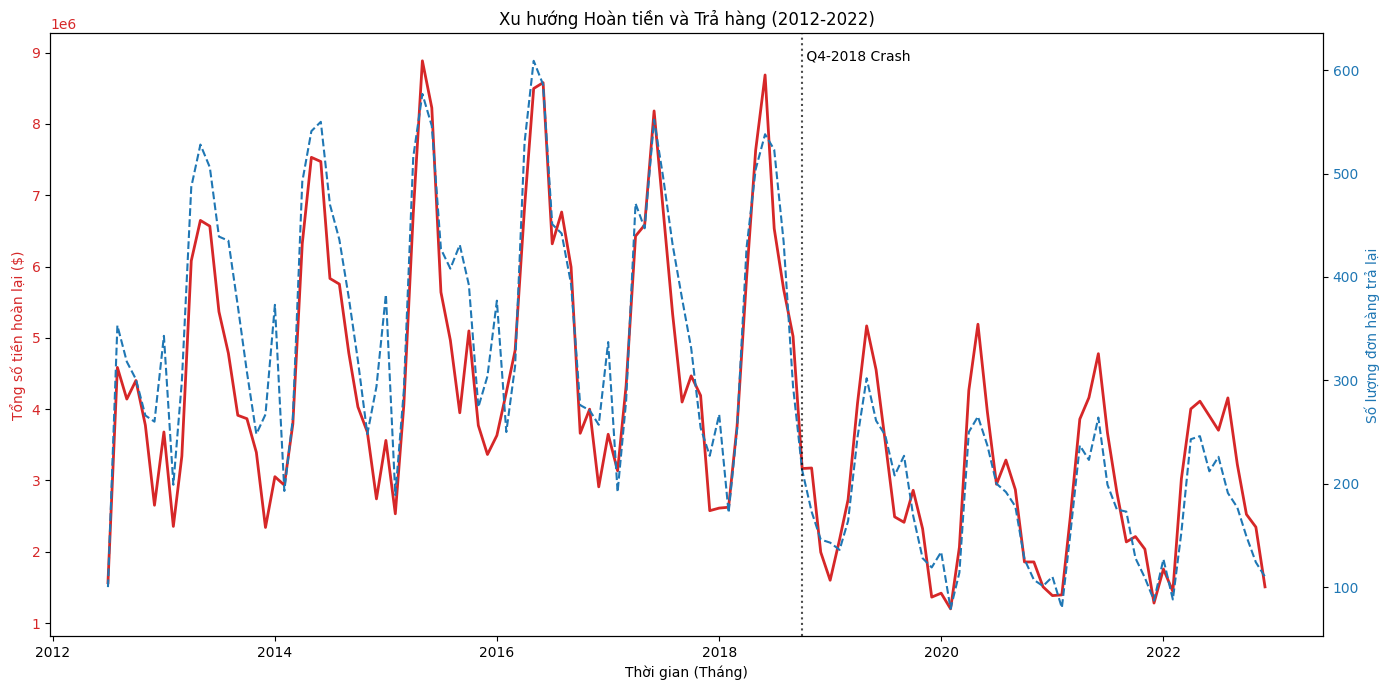

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu từ bảng returns
returns = data['returns'].copy()
# Đảm bảo return_date là định dạng datetime
returns['return_date'] = pd.to_datetime(returns['return_date'])
# Tạo cột tháng để nhóm dữ liệu
returns['month'] = returns['return_date'].dt.to_period('M').dt.to_timestamp()

# 2. Tính toán tổng số tiền hoàn và số lượng đơn trả hàng theo tháng
monthly_returns = returns.groupby('month').agg(
    total_refund_amount=('refund_amount', 'sum'),
    total_return_orders=('order_id', 'nunique')
).reset_index()

# 3. Trực quan hóa dữ liệu
fig, ax1 = plt.subplots(figsize=(14, 7))

# Trục y thứ nhất: Tổng số tiền hoàn lại
color = 'tab:red'
ax1.set_xlabel('Thời gian (Tháng)')
ax1.set_ylabel('Tổng số tiền hoàn lại ($)', color=color)
ax1.plot(monthly_returns['month'], monthly_returns['total_refund_amount'], color=color, linewidth=2, label='Refund Amount')
ax1.tick_params(axis='y', labelcolor=color)

# Trục y thứ hai: Tổng số đơn hàng bị trả
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Số lượng đơn hàng trả lại', color=color)
ax2.plot(monthly_returns['month'], monthly_returns['total_return_orders'], color=color, linestyle='--', label='Return Order Count')
ax2.tick_params(axis='y', labelcolor=color)

# Thêm đường đánh dấu mốc khủng hoảng 2018
plt.axvline(pd.Timestamp('2018-10-01'), color='black', linestyle=':', alpha=0.7)
plt.text(pd.Timestamp('2018-10-01'), monthly_returns['total_return_orders'].max(), ' Q4-2018 Crash', rotation=0)

plt.title('Xu hướng Hoàn tiền và Trả hàng (2012-2022)')
fig.tight_layout()
plt.show()

--- Xác minh chỉ số tồn kho ---
Tỷ lệ thiếu hàng (Stockout): 67.34%
Tỷ lệ tồn kho quá mức (Overstock): 76.26%


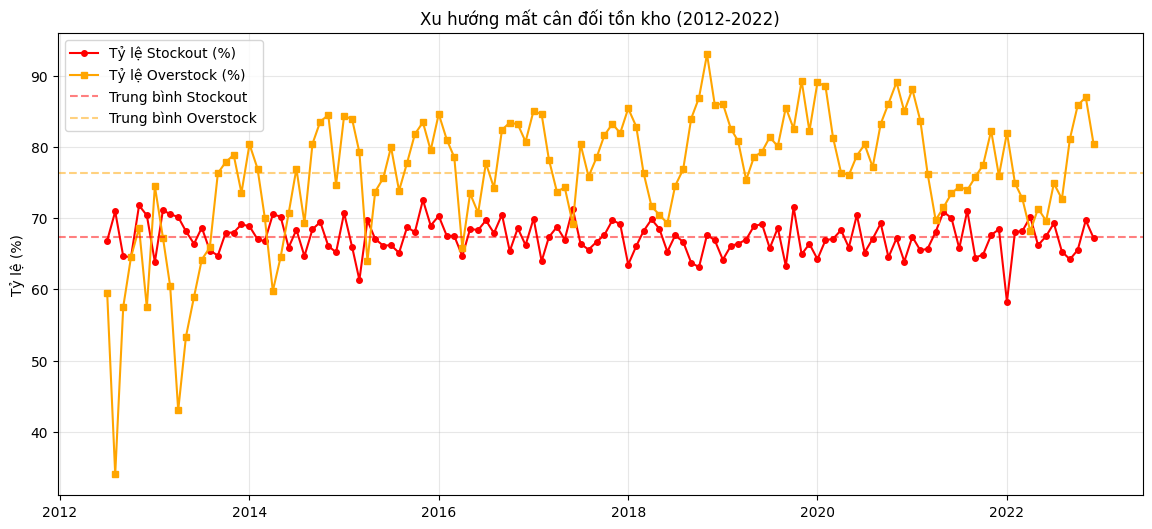


--- Tình trạng tồn kho theo Danh mục ---
            stockout_flag  overstock_flag
category                                 
GenZ            68.292683       71.630295
Outdoor         67.349169       79.852732
Streetwear      67.321083       74.925854
Casual          66.200400       72.594919

Độ tương quan giữa Stockout và Overstock: -0.0368


In [4]:
# --- 1. Xác minh tỷ lệ Stockout và Overstock tổng thể ---
inventory = data['inventory'].copy()

# Tính toán tỷ lệ phần trăm
total_records = len(inventory)
stockout_rate = (inventory['stockout_flag'].sum() / total_records) * 100
overstock_rate = (inventory['overstock_flag'].sum() / total_records) * 100

print(f"--- Xác minh chỉ số tồn kho ---")
print(f"Tỷ lệ thiếu hàng (Stockout): {stockout_rate:.2f}%")
print(f"Tỷ lệ tồn kho quá mức (Overstock): {overstock_rate:.2f}%")

# --- 2. Phân tích sự mất cân đối (Imbalance) theo thời gian ---
# Chuyển đổi sang định dạng tháng để theo dõi xu hướng
inventory['month_dt'] = inventory['snapshot_date'].dt.to_period('M').dt.to_timestamp()
monthly_inventory = inventory.groupby('month_dt').agg({
    'stockout_flag': 'mean',
    'overstock_flag': 'mean'
}) * 100

# Trực quan hóa xu hướng
plt.figure(figsize=(14, 6))
plt.plot(monthly_inventory.index, monthly_inventory['stockout_flag'], label='Tỷ lệ Stockout (%)', color='red', marker='o', markersize=4)
plt.plot(monthly_inventory.index, monthly_inventory['overstock_flag'], label='Tỷ lệ Overstock (%)', color='orange', marker='s', markersize=4)

plt.axhline(y=stockout_rate, color='red', linestyle='--', alpha=0.5, label='Trung bình Stockout')
plt.axhline(y=overstock_rate, color='orange', linestyle='--', alpha=0.5, label='Trung bình Overstock')

plt.title('Xu hướng mất cân đối tồn kho (2012-2022)')
plt.ylabel('Tỷ lệ (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 3. Phân tích "Vừa thừa vừa thiếu" theo Danh mục (Category) ---
# Kiểm tra xem danh mục nào đang bị quản lý kém nhất
cat_inventory = inventory.groupby('category').agg({
    'stockout_flag': 'mean',
    'overstock_flag': 'mean'
}).sort_values('stockout_flag', ascending=False) * 100

print("\n--- Tình trạng tồn kho theo Danh mục ---")
print(cat_inventory)

# --- 4. Tìm điểm "Double Trouble" (Sản phẩm vừa có nguy cơ thiếu vừa có nguy cơ thừa) ---
# Phân tích sự tương quan giữa Stockout và Overstock
correlation = inventory['stockout_flag'].corr(inventory['overstock_flag'])
print(f"\nĐộ tương quan giữa Stockout và Overstock: {correlation:.4f}")

✅ Path found: C:\DATATHON ROUND1
✅ Loaded products.csv
✅ Loaded customers.csv
✅ Loaded promotions.csv
✅ Loaded orders.csv
✅ Loaded order_items.csv
✅ Loaded returns.csv
✅ Loaded reviews.csv
✅ Loaded inventory.csv
✅ Loaded web_traffic.csv

🚀 Starting Analysis...


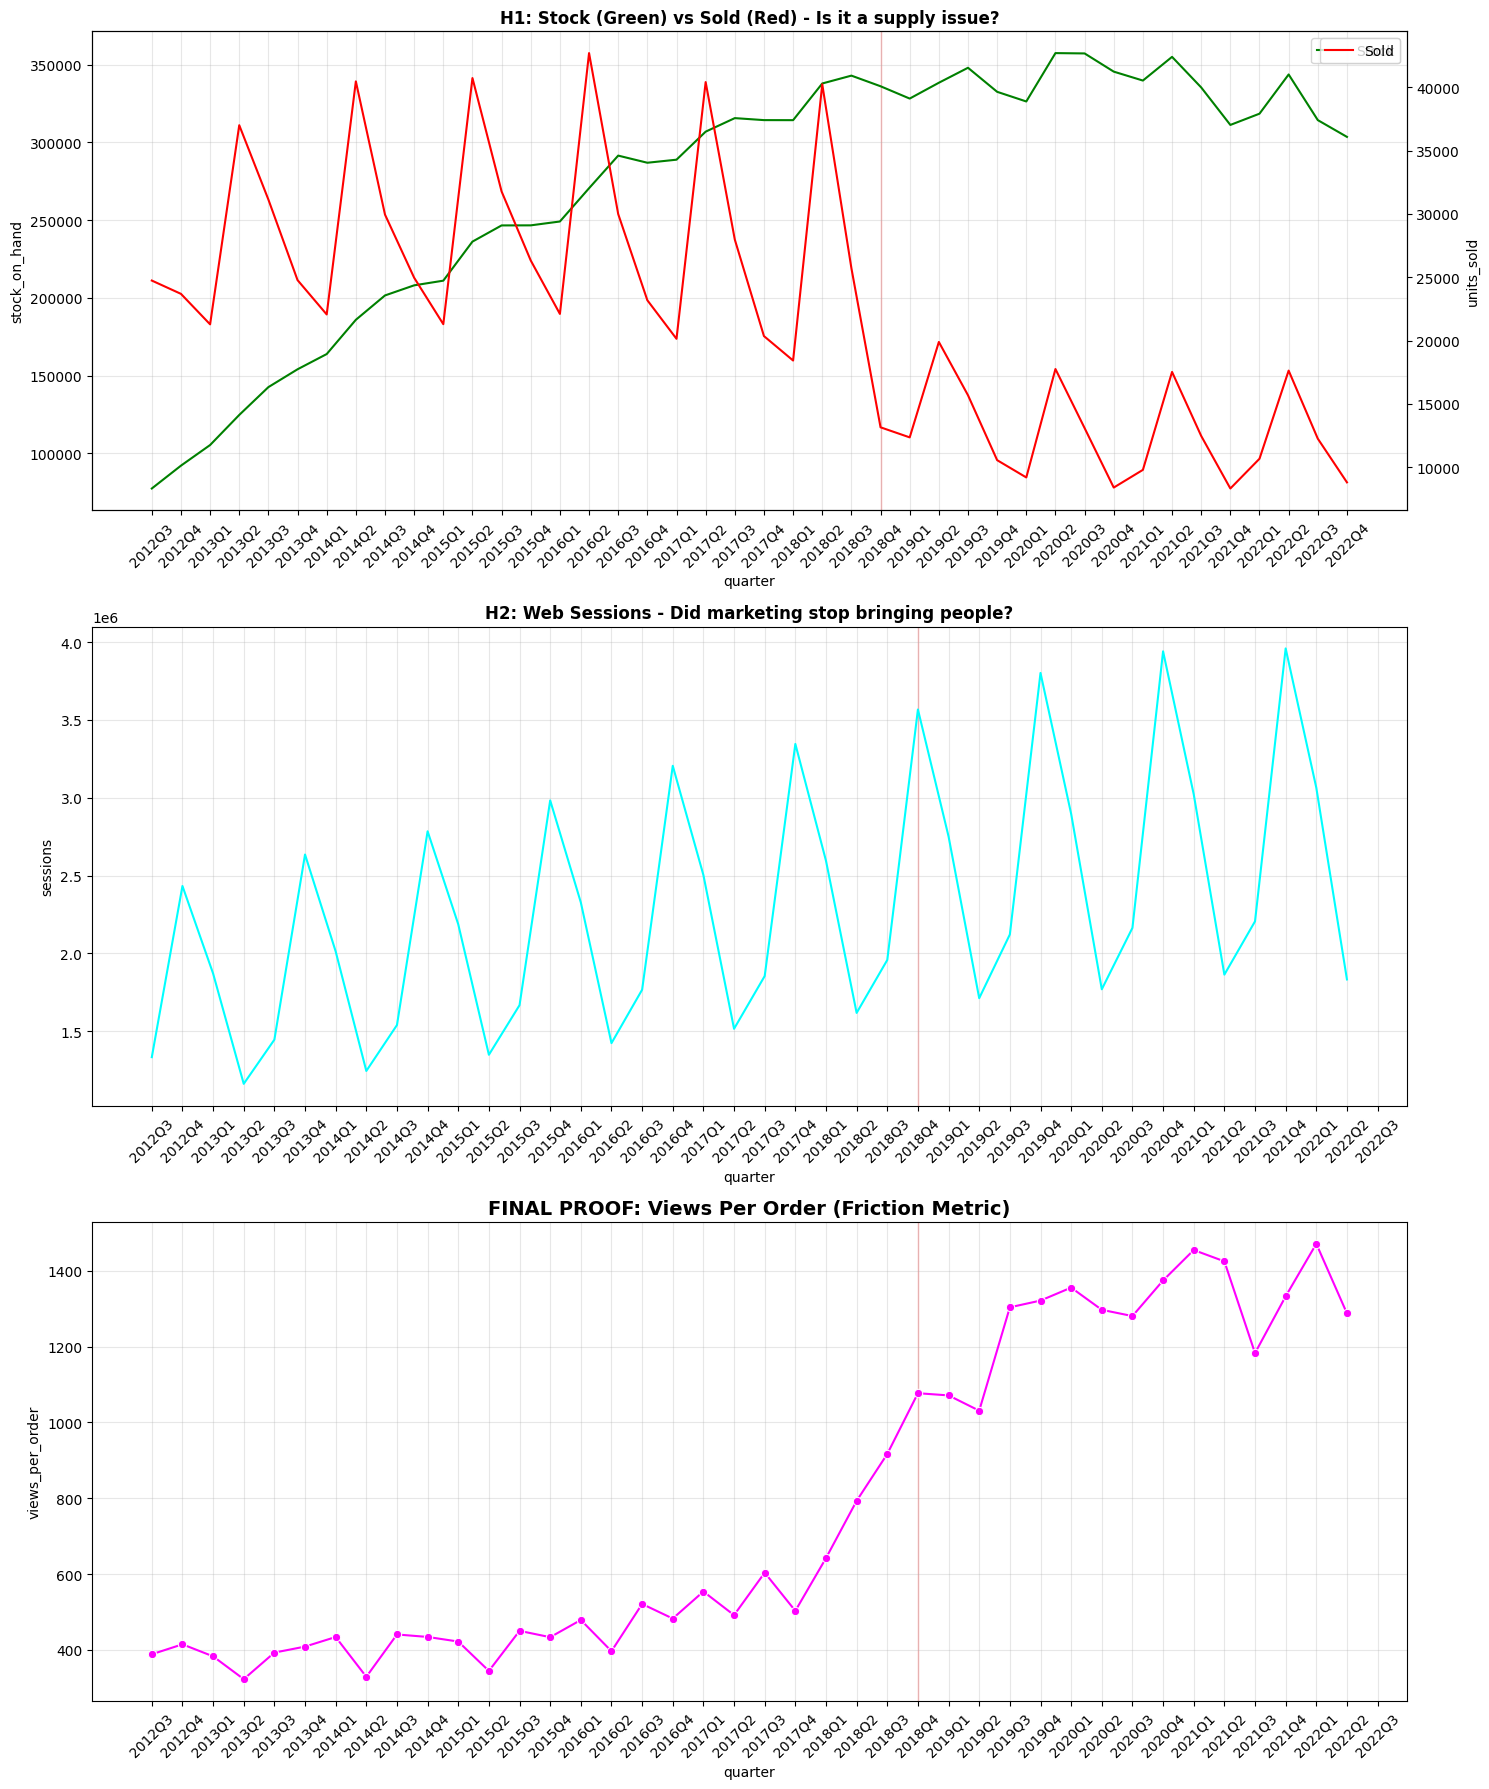

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings

warnings.filterwarnings('ignore')

# --- STEP 1: FIX THE PATH ---
# Change this to the EXACT folder where your CSV files are sitting
# If they are in the same folder as your notebook, just use Path('.')
data_path = Path(r"C:\DATATHON ROUND1") 

# Check if the path actually exists
if not data_path.exists():
    print(f"❌ ERROR: The path {data_path} does not exist. Check your folder name!")
else:
    print(f"✅ Path found: {data_path}")

# --- STEP 2: LOAD DATA WITH ERROR CHECKING ---
files = ['products', 'customers', 'promotions', 'orders', 'order_items', 
         'returns', 'reviews', 'inventory', 'web_traffic']
data = {}

for f in files:
    file_path = data_path / f"{f}.csv"
    if file_path.exists():
        # Handle date parsing for specific files
        parse_dates = []
        if f == 'orders': parse_dates = ['order_date']
        elif f == 'promotions': parse_dates = ['start_date', 'end_date']
        elif f == 'web_traffic': parse_dates = ['date']
        elif f == 'inventory': parse_dates = ['snapshot_date']
        
        data[f] = pd.read_csv(file_path, parse_dates=parse_dates)
        print(f"✅ Loaded {f}.csv")
    else:
        print(f"❌ MISSING: {f}.csv not found in {data_path}")

# --- STEP 3: RUN ANALYSIS IF DATA IS PRESENT ---
if 'orders' in data and 'order_items' in data and 'inventory' in data:
    print("\n🚀 Starting Analysis...")
    
    # Setup Quarters
    orders = data['orders'].copy()
    orders['quarter'] = orders['order_date'].dt.to_period('Q')
    
    # Calculate Order Counts for normalization
    order_counts = orders.groupby('quarter').size().reset_index(name='order_count')
    
    # 1. Inventory Hypo
    inv = data['inventory'].copy()
    inv['quarter'] = inv['snapshot_date'].dt.to_period('Q')
    h1 = inv.groupby('quarter').agg({'stock_on_hand': 'sum', 'units_sold': 'sum'}).reset_index()

    # 2. Marketing Hypo
    traffic = data['web_traffic'].copy()
    traffic['quarter'] = traffic['date'].dt.to_period('Q')
    h3_traffic = traffic.groupby('quarter').agg({'sessions': 'sum', 'page_views': 'sum'}).reset_index()
    
    # 3. Final Proof: Friction (Views per Order)
    friction = h3_traffic.merge(order_counts, on='quarter')
    friction['views_per_order'] = friction['page_views'] / friction['order_count']
    friction['quarter_str'] = friction['quarter'].astype(str)

    # --- STEP 4: VISUALIZATION ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))
    q_labels = h1['quarter'].astype(str)

    # Plot H1: Inventory vs Sales
    sns.lineplot(x=q_labels, y=h1['stock_on_hand'], ax=axes[0], color='green', label='Stock')
    ax0_2 = axes[0].twinx()
    sns.lineplot(x=q_labels, y=h1['units_sold'], ax=ax0_2, color='red', label='Sold')
    axes[0].set_title('H1: Stock (Green) vs Sold (Red) - Is it a supply issue?', fontweight='bold')

    # Plot H2: Traffic
    sns.lineplot(x=q_labels, y=h3_traffic['sessions'], ax=axes[1], color='cyan')
    axes[1].set_title('H2: Web Sessions - Did marketing stop bringing people?', fontweight='bold')

    # Plot H3: The Bug Proof
    sns.lineplot(x=q_labels, y=friction['views_per_order'], ax=axes[2], color='magenta', marker='o')
    axes[2].set_title('FINAL PROOF: Views Per Order (Friction Metric)', fontweight='bold', fontsize=14)

    for ax in axes:
        # Highlight Q4-2018
        if "2018Q4" in list(q_labels):
            ax.axvspan(list(q_labels).index("2018Q4"), list(q_labels).index("2018Q4"), color='red', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n🛑 ANALYSIS CANNOT START: Critical files (orders, order_items, or inventory) are missing.")

--- Data Loading Status ---
✅ products.csv: Loaded (2412 rows)
✅ orders.csv: Loaded (646945 rows)
✅ order_items.csv: Loaded (714669 rows)
✅ promotions.csv: Loaded (50 rows)
✅ inventory.csv: Loaded (60247 rows)
✅ web_traffic.csv: Loaded (3652 rows)
✅ returns.csv: Loaded (39939 rows)
✅ reviews.csv: Loaded (113551 rows)

🚀 Core data verified. Starting 5-Hypothesis Audit...


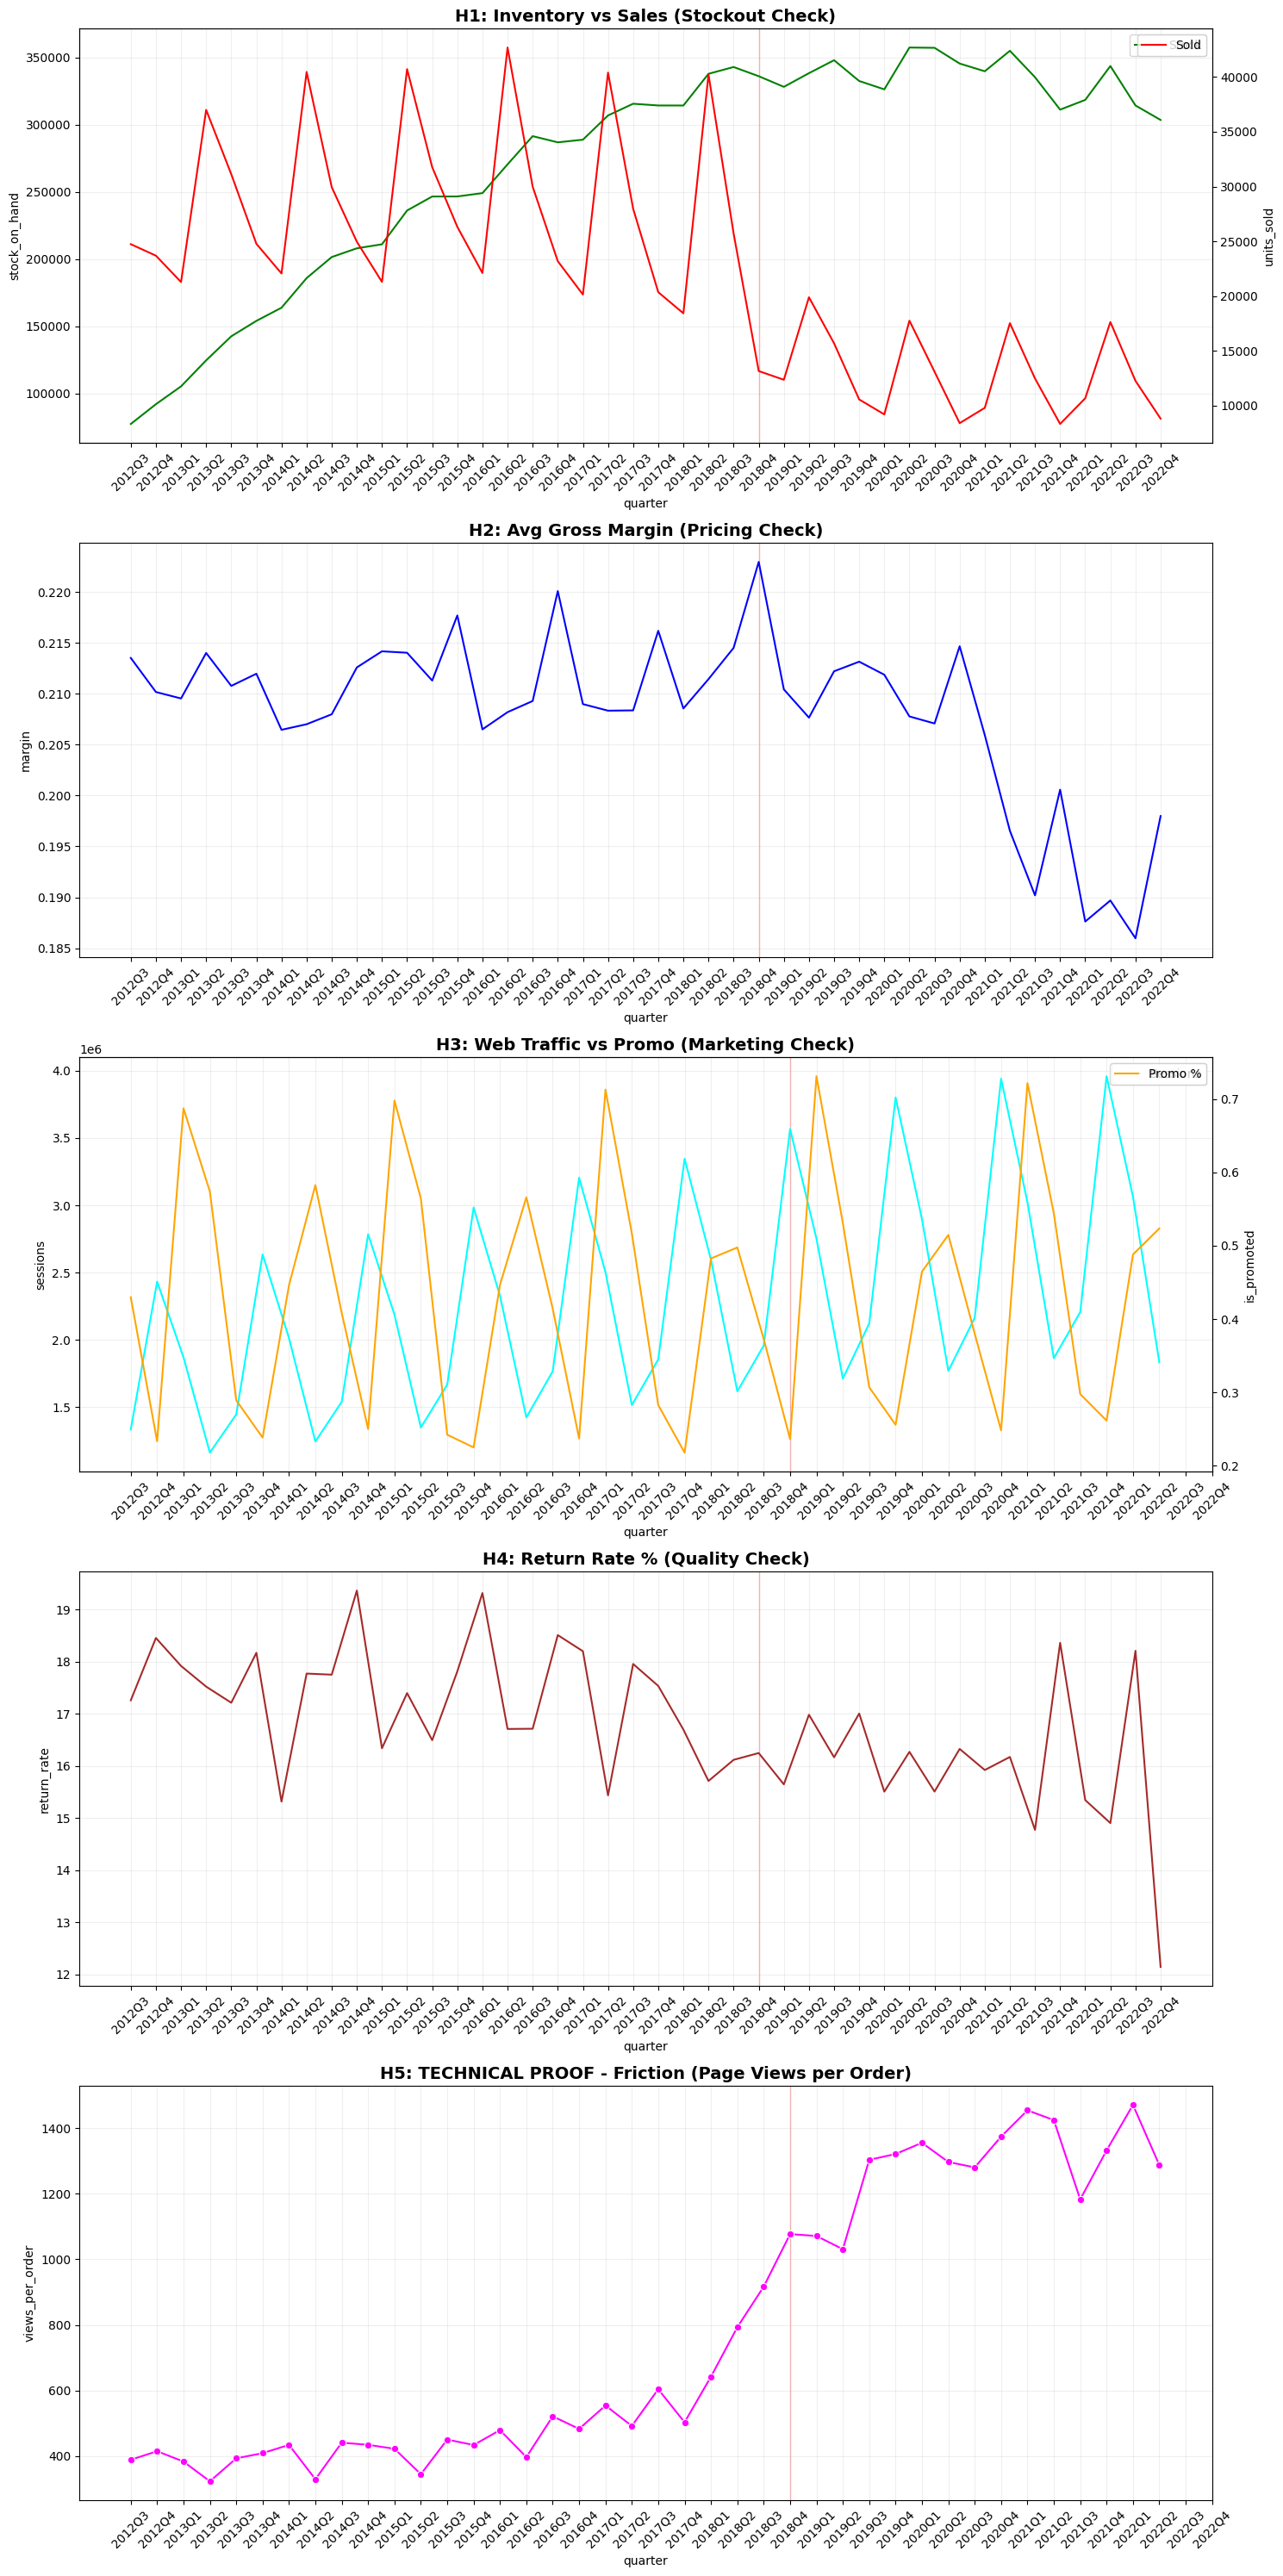

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# 1. SETUP PATH - Double check this is where your CSVs are stored
data_path = Path(r"C:\DATATHON ROUND1")

files = ['products', 'orders', 'order_items', 'promotions', 'inventory', 'web_traffic', 'returns', 'reviews']
data = {}

print("--- Data Loading Status ---")
for f in files:
    path = data_path / f"{f}.csv"
    if path.exists():
        # Force specific date parsing to prevent plotting errors later
        dates = ['order_date'] if f == 'orders' else (['date'] if f == 'web_traffic' else (['snapshot_date'] if f == 'inventory' else None))
        data[f] = pd.read_csv(path, parse_dates=dates)
        print(f"✅ {f}.csv: Loaded ({len(data[f])} rows)")
    else:
        print(f"❌ {f}.csv: NOT FOUND in {data_path}")

# 2. RUN AUDIT ONLY IF CORE FILES ARE READY
required = ['orders', 'order_items', 'inventory', 'web_traffic', 'products']
if all(k in data for k in required):
    print("\n🚀 Core data verified. Starting 5-Hypothesis Audit...")
    
    # Process Quarters
    orders = data['orders'].copy()
    orders['quarter'] = orders['order_date'].dt.to_period('Q')
    q_labels = orders['quarter'].sort_values().unique().astype(str)
    order_counts = orders.groupby('quarter').size().reset_index(name='order_count')
    
    # H1: Inventory (Supply vs Demand)
    inv = data['inventory'].copy()
    inv['quarter'] = inv['snapshot_date'].dt.to_period('Q')
    h1 = inv.groupby('quarter').agg({'stock_on_hand': 'sum', 'units_sold': 'sum'}).reset_index()
    
    # H2: Financial (Margins)
    oi = data['order_items'].merge(orders[['order_id', 'quarter']], on='order_id')
    oi = oi.merge(data['products'][['product_id', 'price', 'cogs']], on='product_id')
    oi['margin'] = (oi['price'] - oi['cogs']) / oi['price']
    h2 = oi.groupby('quarter').agg({'margin': 'mean', 'unit_price': 'mean'}).reset_index()
    
    # H3: Marketing (Traffic vs Promotion)
    oi['is_promoted'] = oi['promo_id'].notnull().astype(int)
    h3_promo = oi.groupby('quarter')['is_promoted'].mean().reset_index()
    traffic = data['web_traffic'].copy()
    traffic['quarter'] = traffic['date'].dt.to_period('Q')
    h3_traffic = traffic.groupby('quarter').agg({'sessions': 'sum', 'page_views': 'sum'}).reset_index()
    h3 = h3_promo.merge(h3_traffic, on='quarter')
    
    # H4: Quality (Returns)
    ret_q = data['returns'].groupby('order_id')['return_quantity'].sum().reset_index()
    h4_merged = orders.merge(ret_q, on='order_id', how='left').fillna(0)
    h4 = h4_merged.groupby('quarter').agg({'return_quantity': 'sum'}).reset_index()
    h4 = h4.merge(order_counts, on='quarter')
    h4['return_rate'] = (h4['return_quantity'] / h4['order_count']) * 100
    
    # H5: Technical (The Friction Proof)
    h5 = h3_traffic.merge(order_counts, on='quarter')
    h5['views_per_order'] = h5['page_views'] / h5['order_count']
    
    # 3. DASHBOARD VISUALIZATION
    fig, axes = plt.subplots(5, 1, figsize=(15, 30))
    
    def style_ax(ax, title):
        ax.set_title(title, fontweight='bold', fontsize=14)
        if "2018Q4" in list(q_labels):
            idx = list(q_labels).index("2018Q4")
            ax.axvspan(idx, idx, color='red', alpha=0.3, label='Potential Bug')
        ax.set_xticks(range(len(q_labels)))
        ax.set_xticklabels(q_labels, rotation=45)
        ax.grid(True, alpha=0.2)

    # Plotting
    sns.lineplot(x=h1['quarter'].astype(str), y=h1['stock_on_hand'], ax=axes[0], color='green', label='Stock')
    ax0_2 = axes[0].twinx(); sns.lineplot(x=h1['quarter'].astype(str), y=h1['units_sold'], ax=ax0_2, color='red', label='Sold')
    style_ax(axes[0], 'H1: Inventory vs Sales (Stockout Check)')

    sns.lineplot(x=h2['quarter'].astype(str), y=h2['margin'], ax=axes[1], color='blue')
    style_ax(axes[1], 'H2: Avg Gross Margin (Pricing Check)')

    sns.lineplot(x=h3['quarter'].astype(str), y=h3['sessions'], ax=axes[2], color='cyan', label='Sessions')
    ax2_2 = axes[2].twinx(); sns.lineplot(x=h3['quarter'].astype(str), y=h3['is_promoted'], ax=ax2_2, color='orange', label='Promo %')
    style_ax(axes[2], 'H3: Web Traffic vs Promo (Marketing Check)')

    sns.lineplot(x=h4['quarter'].astype(str), y=h4['return_rate'], ax=axes[3], color='brown')
    style_ax(axes[3], 'H4: Return Rate % (Quality Check)')

    sns.lineplot(x=h5['quarter'].astype(str), y=h5['views_per_order'], ax=axes[4], color='magenta', marker='o')
    style_ax(axes[4], 'H5: TECHNICAL PROOF - Friction (Page Views per Order)')

    plt.tight_layout()
    plt.show()
else:
    print("\n🛑 ERROR: Cannot start audit. Please fix the file path or check for missing CSVs above.")

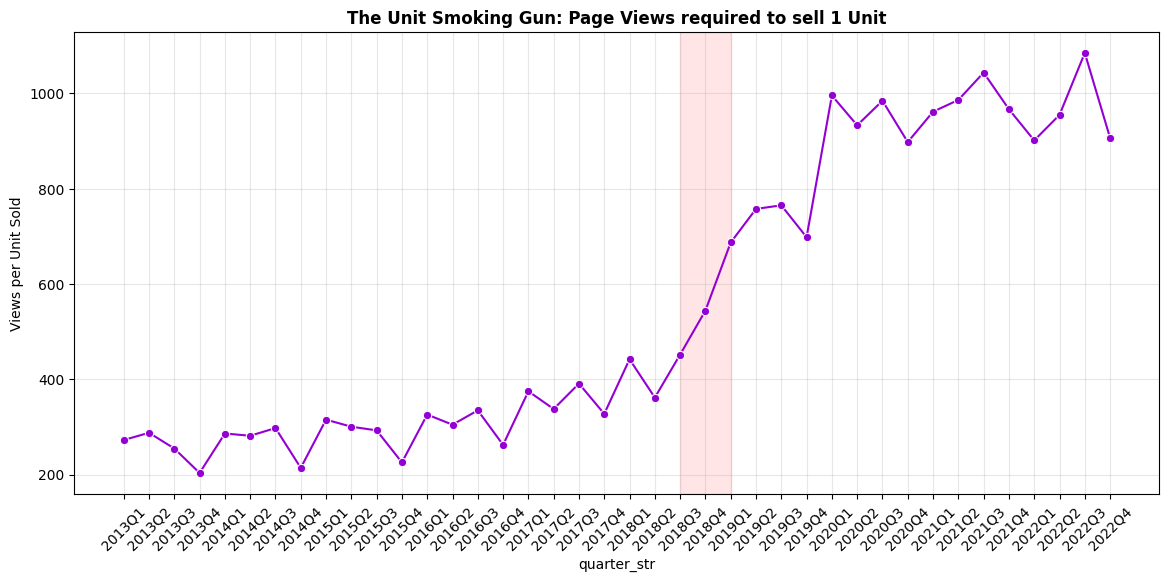

In [7]:
# 1. Aggregate Units Sold from the Inventory Table (Operational Reality)
inv_units = data['inventory'].copy()
inv_units['quarter'] = inv_units['snapshot_date'].dt.to_period('Q')
q_units = inv_units.groupby('quarter')['units_sold'].sum().reset_index()

# 2. Aggregate Page Views from Web Traffic
traffic_intent = data['web_traffic'].copy()
traffic_intent['quarter'] = traffic_intent['date'].dt.to_period('Q')
q_views = traffic_intent.groupby('quarter')['page_views'].sum().reset_index()

# 3. Merge and Calculate Friction
unit_friction = q_views.merge(q_units, on='quarter')
unit_friction['views_per_unit'] = unit_friction['page_views'] / unit_friction['units_sold']
unit_friction['quarter_str'] = unit_friction['quarter'].astype(str)

# 4. Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(data=unit_friction, x='quarter_str', y='views_per_unit', marker='o', color='darkviolet')
plt.title('The Unit Smoking Gun: Page Views required to sell 1 Unit', fontweight='bold')
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1, label='The Tech Crash')
plt.xticks(rotation=45)
plt.ylabel('Views per Unit Sold')
plt.grid(True, alpha=0.3)
plt.show()

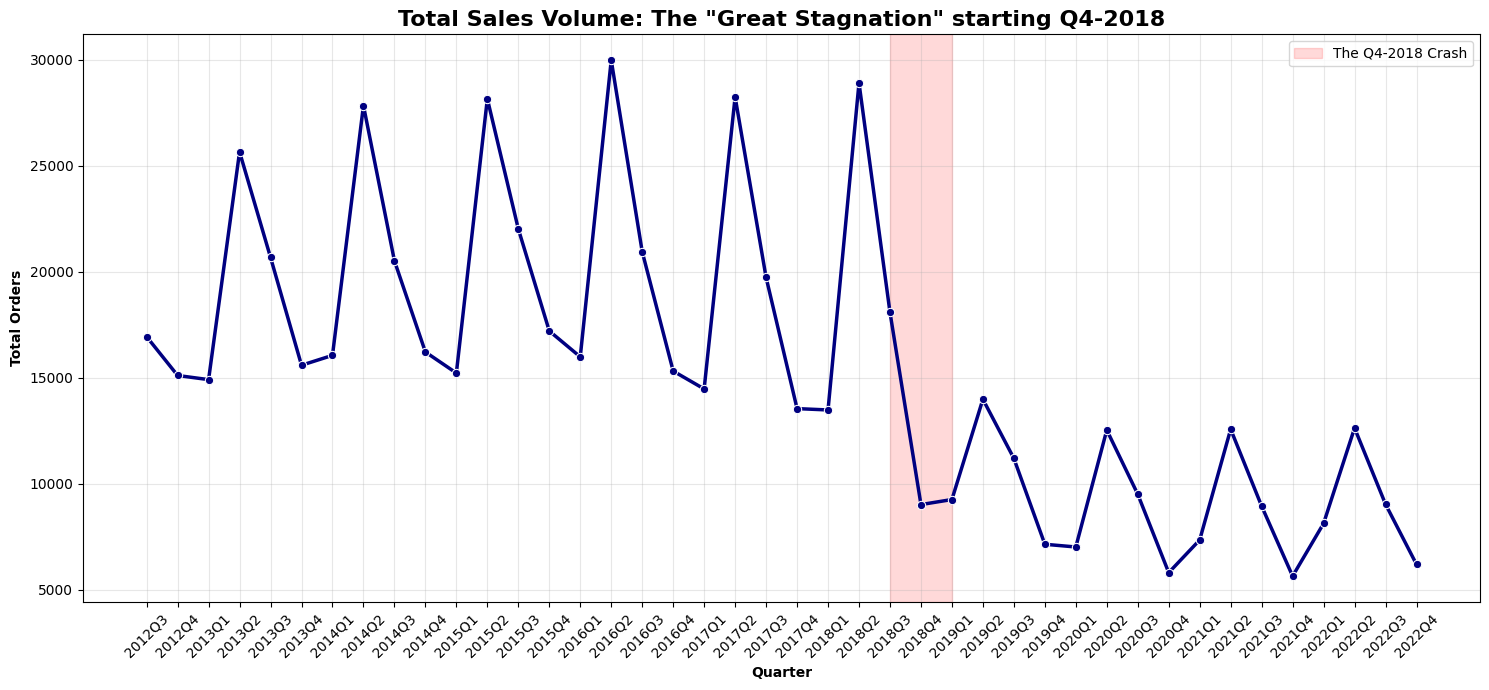

In [8]:
# 1. Prepare the Sales Data
sales_trend = data['orders'].copy()
sales_trend['order_date'] = pd.to_datetime(sales_trend['order_date'])
sales_trend['quarter'] = sales_trend['order_date'].dt.to_period('Q')

# 2. Group by Quarter
quarterly_sales = sales_trend.groupby('quarter').size().reset_index(name='total_orders')
quarterly_sales['quarter_str'] = quarterly_sales['quarter'].astype(str)

# 3. Visualization
plt.figure(figsize=(15, 7))
sns.lineplot(data=quarterly_sales, x='quarter_str', y='total_orders', marker='o', color='navy', linewidth=2.5)

# Highlight the Crash Zone
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.15, label='The Q4-2018 Crash')

plt.title('Total Sales Volume: The "Great Stagnation" starting Q4-2018', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.ylabel('Total Orders', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

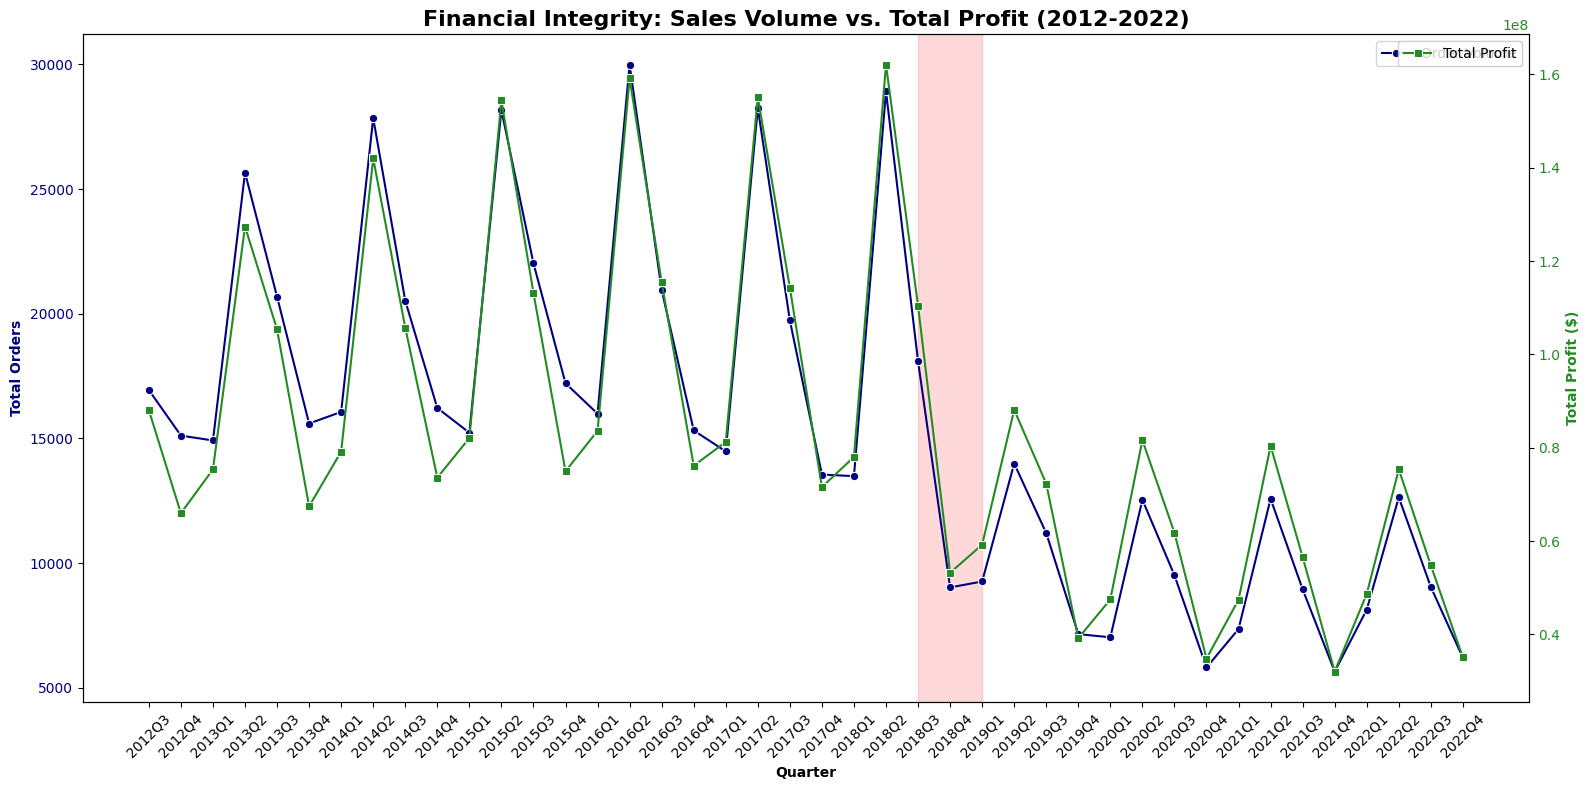

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load the necessary files
# Ensure 'data_path' is set to your local CSV folder
data_path = Path(r"C:\DATATHON ROUND1")

orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Calculate Profit per Item
# Profit = (Price - COGS) * Quantity
items_merged = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id')
items_merged['item_profit'] = (items_merged['price'] - items_merged['cogs']) * items_merged['quantity']

# 3. Merge with Orders to get the Date
profit_data = items_merged.merge(orders[['order_id', 'order_date']], on='order_id')
profit_data['quarter'] = profit_data['order_date'].dt.to_period('Q')

# 4. Aggregate Quarterly Sales and Profit
quarterly_perf = profit_data.groupby('quarter').agg({
    'order_id': 'nunique', # Total Orders
    'item_profit': 'sum'   # Total Profit
}).reset_index()

quarterly_perf.rename(columns={'order_id': 'total_orders', 'item_profit': 'total_profit'}, inplace=True)
quarterly_perf['quarter_str'] = quarterly_perf['quarter'].astype(str)

# 5. Visualization
fig, ax1 = plt.subplots(figsize=(16, 8))

# Plot Sales Volume (Orders)
sns.lineplot(data=quarterly_perf, x='quarter_str', y='total_orders', ax=ax1, color='navy', marker='o', label='Order Volume')
ax1.set_ylabel('Total Orders', fontweight='bold', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

# Create a second y-axis for Profit
ax2 = ax1.twinx()
sns.lineplot(data=quarterly_perf, x='quarter_str', y='total_profit', ax=ax2, color='forestgreen', marker='s', label='Total Profit')
ax2.set_ylabel('Total Profit ($)', fontweight='bold', color='forestgreen')
ax2.tick_params(axis='y', labelcolor='forestgreen')

# Formatting
ax1.set_title('Financial Integrity: Sales Volume vs. Total Profit (2012-2022)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Quarter', fontweight='bold')
ax1.set_xticks(range(len(quarterly_perf)))
ax1.set_xticklabels(quarterly_perf['quarter_str'], rotation=45)

# Highlight the Q4-2018 Crash
ax1.axvspan('2018Q3', '2019Q1', color='red', alpha=0.15, label='The Crash Zone')

fig.tight_layout()
plt.show()

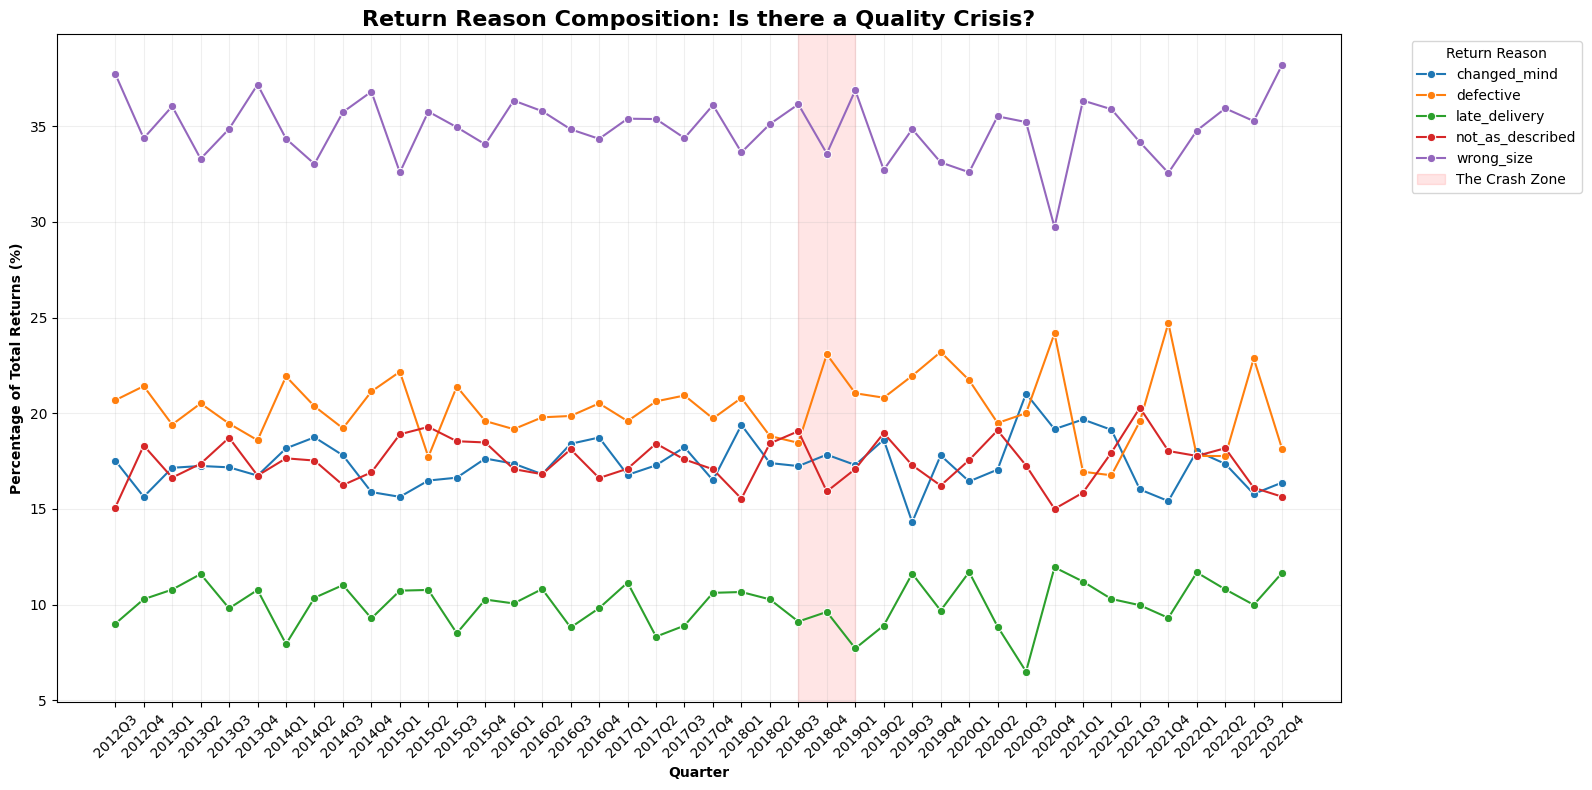

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load and Prep Data
data_path = Path(r"C:\DATATHON ROUND1")
returns = pd.read_csv(data_path / "returns.csv", parse_dates=['return_date'])

# Group by Quarter and Reason
returns['quarter'] = returns['return_date'].dt.to_period('Q').astype(str)
reason_counts = returns.groupby(['quarter', 'return_reason']).size().reset_index(name='count')

# 2. Calculate Percentages (Composition)
# This shows the "Mix" of reasons, so we can see if one reason started dominating
total_per_quarter = returns.groupby('quarter').size().reset_index(name='total_q')
reason_pct = reason_counts.merge(total_per_quarter, on='quarter')
reason_pct['percentage'] = (reason_pct['count'] / reason_pct['total_q']) * 100

# 3. Visualization (Stacked Area or Line Chart)
plt.figure(figsize=(16, 8))
sns.lineplot(data=reason_pct, x='quarter', y='percentage', hue='return_reason', marker='o')

# Formatting
plt.title('Return Reason Composition: Is there a Quality Crisis?', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Total Returns (%)', fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)

# Highlight the Crash Zone
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1, label='The Crash Zone')

plt.legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

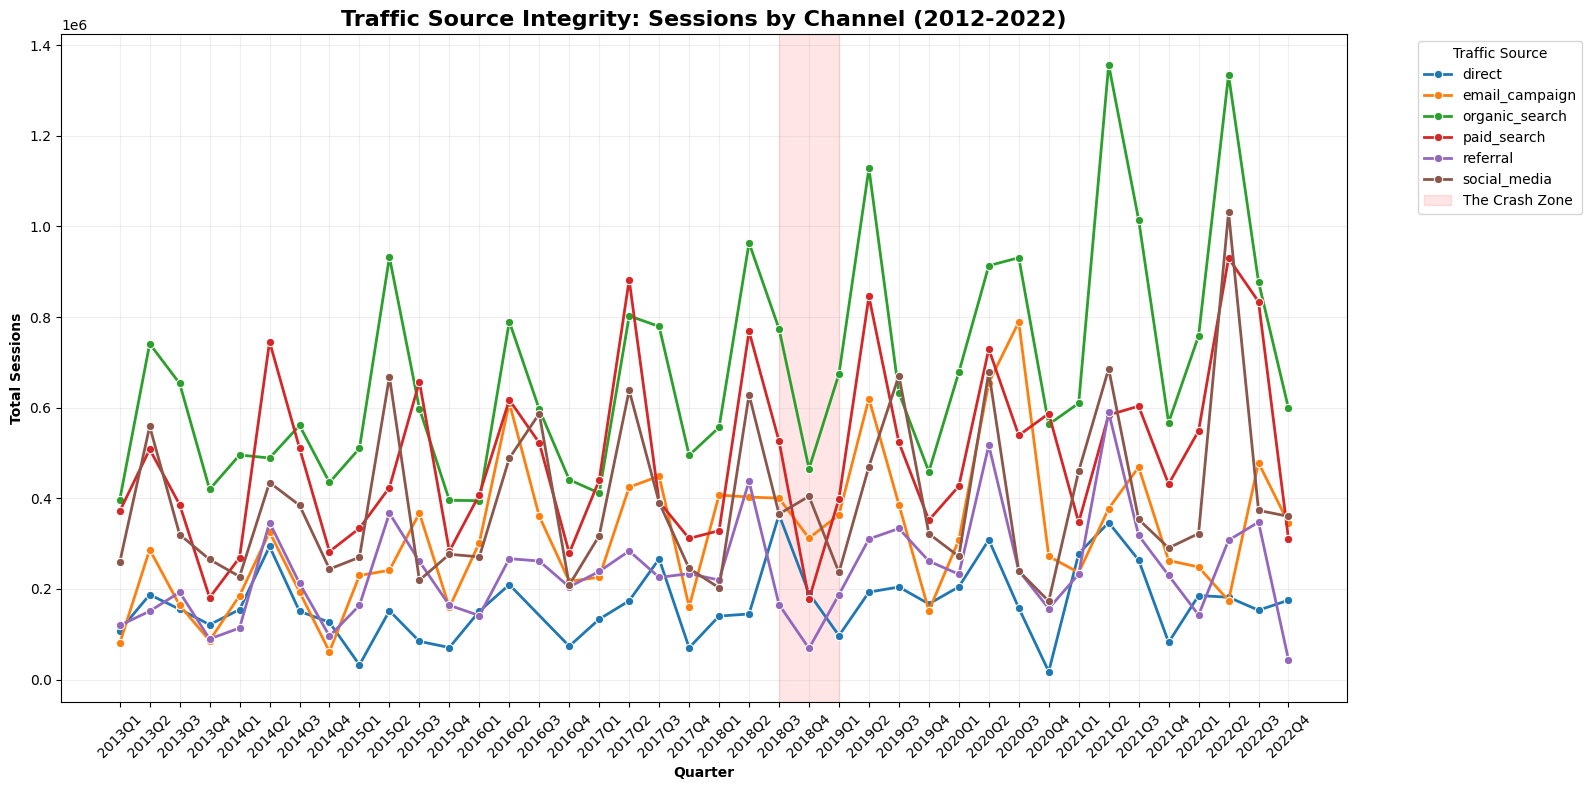

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data
data_path = Path(r"C:\DATATHON ROUND1")
traffic = pd.read_csv(data_path / "web_traffic.csv", parse_dates=['date'])

# 2. Prepare Time Periods (Quarterly is best for identifying the Q4-2018 crash)
traffic['quarter'] = traffic['date'].dt.to_period('Q').astype(str)

# 3. Aggregate Sessions by Quarter and Source
source_trend = traffic.groupby(['quarter', 'traffic_source'])['sessions'].sum().reset_index()

# 4. Visualization
plt.figure(figsize=(16, 8))

# We use a line plot to see the individual health of each channel
sns.lineplot(data=source_trend, x='quarter', y='sessions', hue='traffic_source', marker='o', linewidth=2)

# Formatting
plt.title('Traffic Source Integrity: Sessions by Channel (2012-2022)', fontsize=16, fontweight='bold')
plt.ylabel('Total Sessions', fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)

# Highlight the Q4-2018 Crash Zone
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1, label='The Crash Zone')

plt.legend(title='Traffic Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

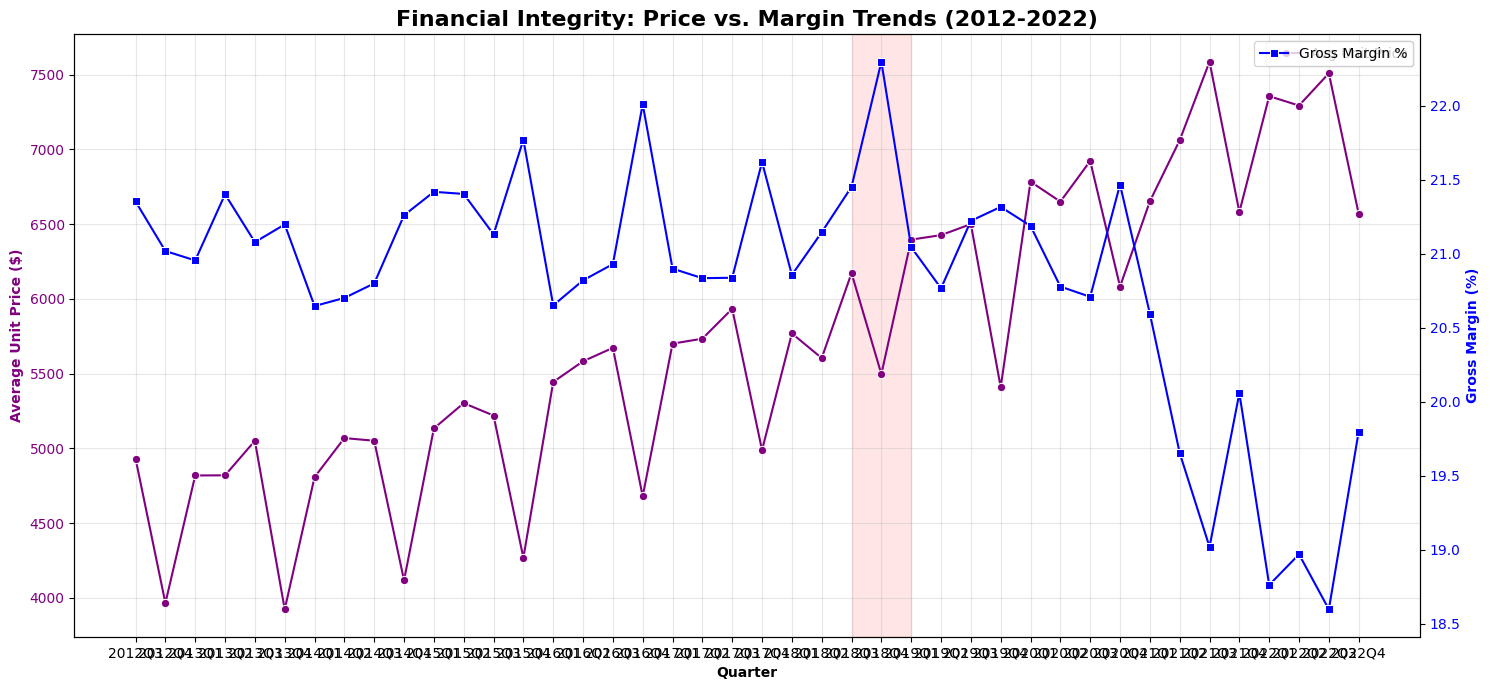

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data (Update path if needed)
data_path = Path(r"C:\DATATHON ROUND1")

orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Merge Data to link Dates with Financials
# We need price and cogs from products, and quantity from order_items
df_fin = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id')
df_fin = df_fin.merge(orders[['order_id', 'order_date']], on='order_id')

# 3. Calculate Metrics
df_fin['quarter'] = df_fin['order_date'].dt.to_period('Q')
df_fin['gross_margin_pct'] = ((df_fin['price'] - df_fin['cogs']) / df_fin['price']) * 100

# Aggregate by Quarter
quarterly_fin = df_fin.groupby('quarter').agg({
    'price': 'mean',           # Average Unit Price
    'gross_margin_pct': 'mean' # Average Gross Margin %
}).reset_index()

quarterly_fin['quarter_str'] = quarterly_fin['quarter'].astype(str)

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Average Unit Price
sns.lineplot(data=quarterly_fin, x='quarter_str', y='price', ax=ax1, color='purple', marker='o', label='Avg Unit Price')
ax1.set_ylabel('Average Unit Price ($)', fontweight='bold', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Create second axis for Gross Margin
ax2 = ax1.twinx()
sns.lineplot(data=quarterly_fin, x='quarter_str', y='gross_margin_pct', ax=ax2, color='blue', marker='s', label='Gross Margin %')
ax2.set_ylabel('Gross Margin (%)', fontweight='bold', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Formatting
ax1.set_title('Financial Integrity: Price vs. Margin Trends (2012-2022)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Quarter', fontweight='bold')
plt.xticks(rotation=45)
ax1.grid(True, alpha=0.3)

# Highlight the Q4-2018 Drop
ax1.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1, label='The 2018 Crash')

fig.tight_layout()
plt.show()

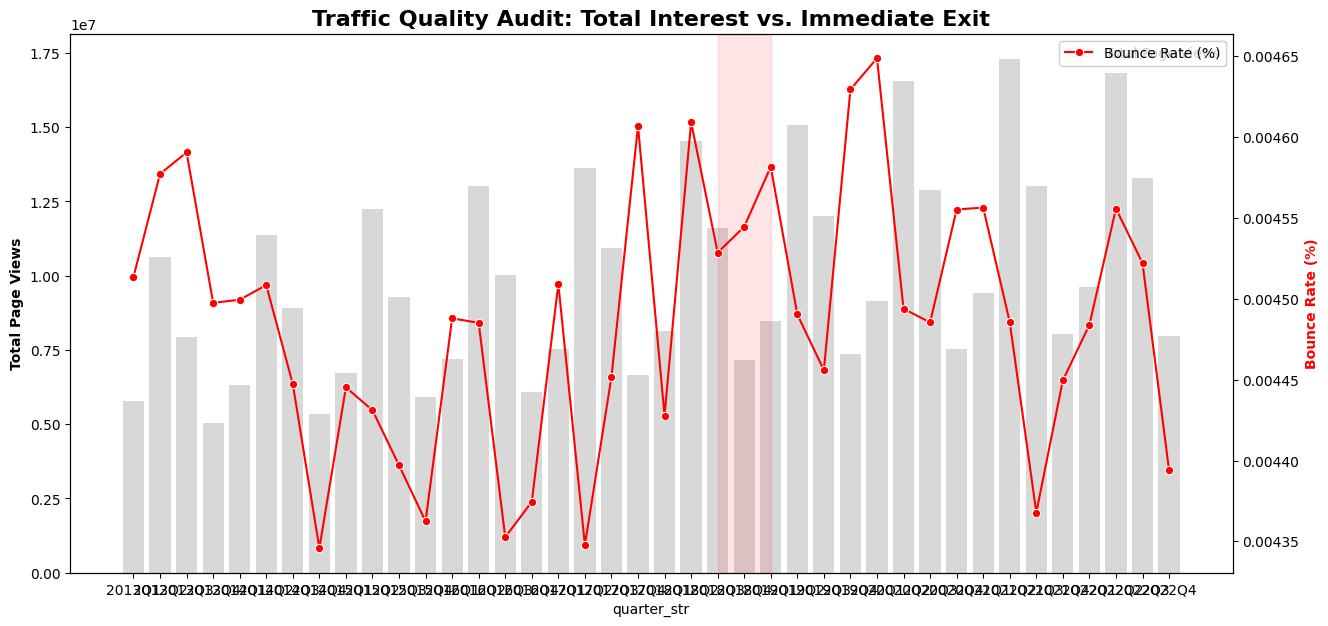

In [13]:
# 1. Aggregate Page Views and Sessions
traffic_stats = data['web_traffic'].copy()
traffic_stats['quarter'] = traffic_stats['date'].dt.to_period('Q')

q_traffic = traffic_stats.groupby('quarter').agg({
    'page_views': 'sum',
    'sessions': 'sum',
    'bounce_rate': 'mean' # CRITICAL: The "Interest" filter
}).reset_index()

# 2. Add Business Outcomes
q_outcomes = data['orders'].copy()
q_outcomes['quarter'] = q_outcomes['order_date'].dt.to_period('Q')
q_sales = q_outcomes.groupby('quarter').size().reset_index(name='order_count')

# 3. Merge and Calculate Quality Metrics
quality_audit = q_traffic.merge(q_sales, on='quarter')
quality_audit['views_per_session'] = quality_audit['page_views'] / quality_audit['sessions']
quality_audit['quarter_str'] = quality_audit['quarter'].astype(str)

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Page Views
sns.barplot(data=quality_audit, x='quarter_str', y='page_views', alpha=0.3, color='grey', ax=ax1, label='Total Page Views')
ax1.set_ylabel('Total Page Views', fontweight='bold')

# Plot Bounce Rate on second axis
ax2 = ax1.twinx()
sns.lineplot(data=quality_audit, x='quarter_str', y='bounce_rate', marker='o', color='red', ax=ax2, label='Bounce Rate (%)')
ax2.set_ylabel('Bounce Rate (%)', fontweight='bold', color='red')

plt.title('Traffic Quality Audit: Total Interest vs. Immediate Exit', fontsize=16, fontweight='bold')
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1)
plt.xticks(rotation=45)
plt.show()

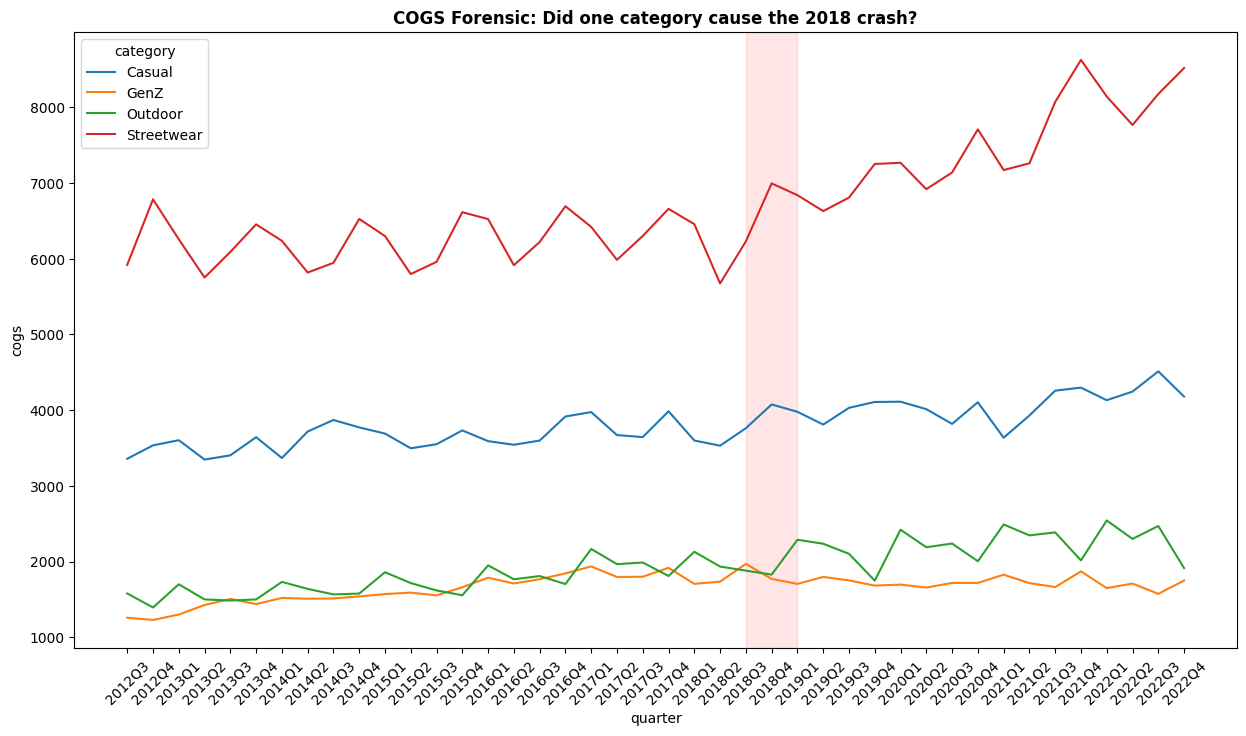

In [14]:
# 1. Merge Order Items with Products to get Category-level COGS
cogs_audit = data['order_items'].merge(data['products'][['product_id', 'category', 'cogs', 'price']], on='product_id')
cogs_audit = cogs_audit.merge(data['orders'][['order_id', 'order_date']], on='order_id')
cogs_audit['quarter'] = cogs_audit['order_date'].dt.to_period('Q')

# 2. Calculate Average COGS and Margin by Category
cat_fin = cogs_audit.groupby(['quarter', 'category']).agg({
    'cogs': 'mean',
    'price': 'mean'
}).reset_index()
cat_fin['margin'] = (cat_fin['price'] - cat_fin['cogs']) / cat_fin['price']

# 3. Visualization: COGS Trend by Category
plt.figure(figsize=(15, 8))
sns.lineplot(data=cat_fin, x=cat_fin['quarter'].astype(str), y='cogs', hue='category')
plt.title('COGS Forensic: Did one category cause the 2018 crash?', fontweight='bold')
plt.axvspan('2018Q3', '2019Q1', color='red', alpha=0.1)
plt.xticks(rotation=45)
plt.show()

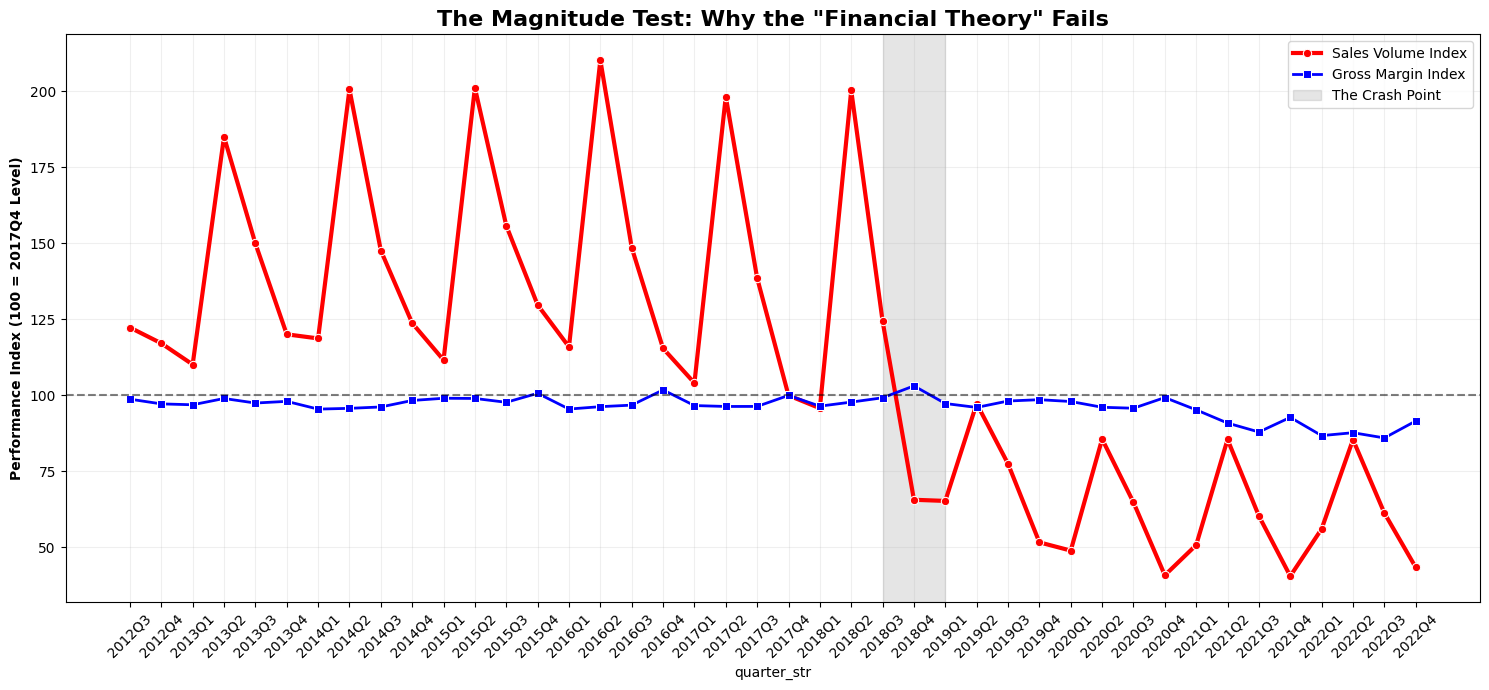

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data
data_path = Path(r"C:\DATATHON ROUND1")
orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Financial Calculations
df = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id')
df = df.merge(orders[['order_id', 'order_date']], on='order_id')
df['quarter'] = df['order_date'].dt.to_period('Q')
df['margin_val'] = (df['price'] - df['cogs']) / df['price']

# 3. Aggregate Quarterly Metrics
magnitude_df = df.groupby('quarter').agg({
    'quantity': 'sum',      # Sales Volume (Units)
    'margin_val': 'mean'    # Profit Margin (%)
}).reset_index()

# 4. Normalize to Baseline (Index 100) 
# We use 2017Q4 as the baseline (The last "Healthy" quarter)
baseline = magnitude_df[magnitude_df['quarter'] == '2017Q4'].iloc[0]
magnitude_df['volume_index'] = (magnitude_df['quantity'] / baseline['quantity']) * 100
magnitude_df['margin_index'] = (magnitude_df['margin_val'] / baseline['margin_val']) * 100
magnitude_df['quarter_str'] = magnitude_df['quarter'].astype(str)

# 5. Visualization
plt.figure(figsize=(15, 7))
sns.lineplot(data=magnitude_df, x='quarter_str', y='volume_index', label='Sales Volume Index', marker='o', color='red', linewidth=3)
sns.lineplot(data=magnitude_df, x='quarter_str', y='margin_index', label='Gross Margin Index', marker='s', color='blue', linewidth=2)

# Formatting
plt.axhline(100, color='black', linestyle='--', alpha=0.5) # Baseline line
plt.axvspan('2018Q3', '2019Q1', color='grey', alpha=0.2, label='The Crash Point')
plt.title('The Magnitude Test: Why the "Financial Theory" Fails', fontsize=16, fontweight='bold')
plt.ylabel('Performance Index (100 = 2017Q4 Level)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

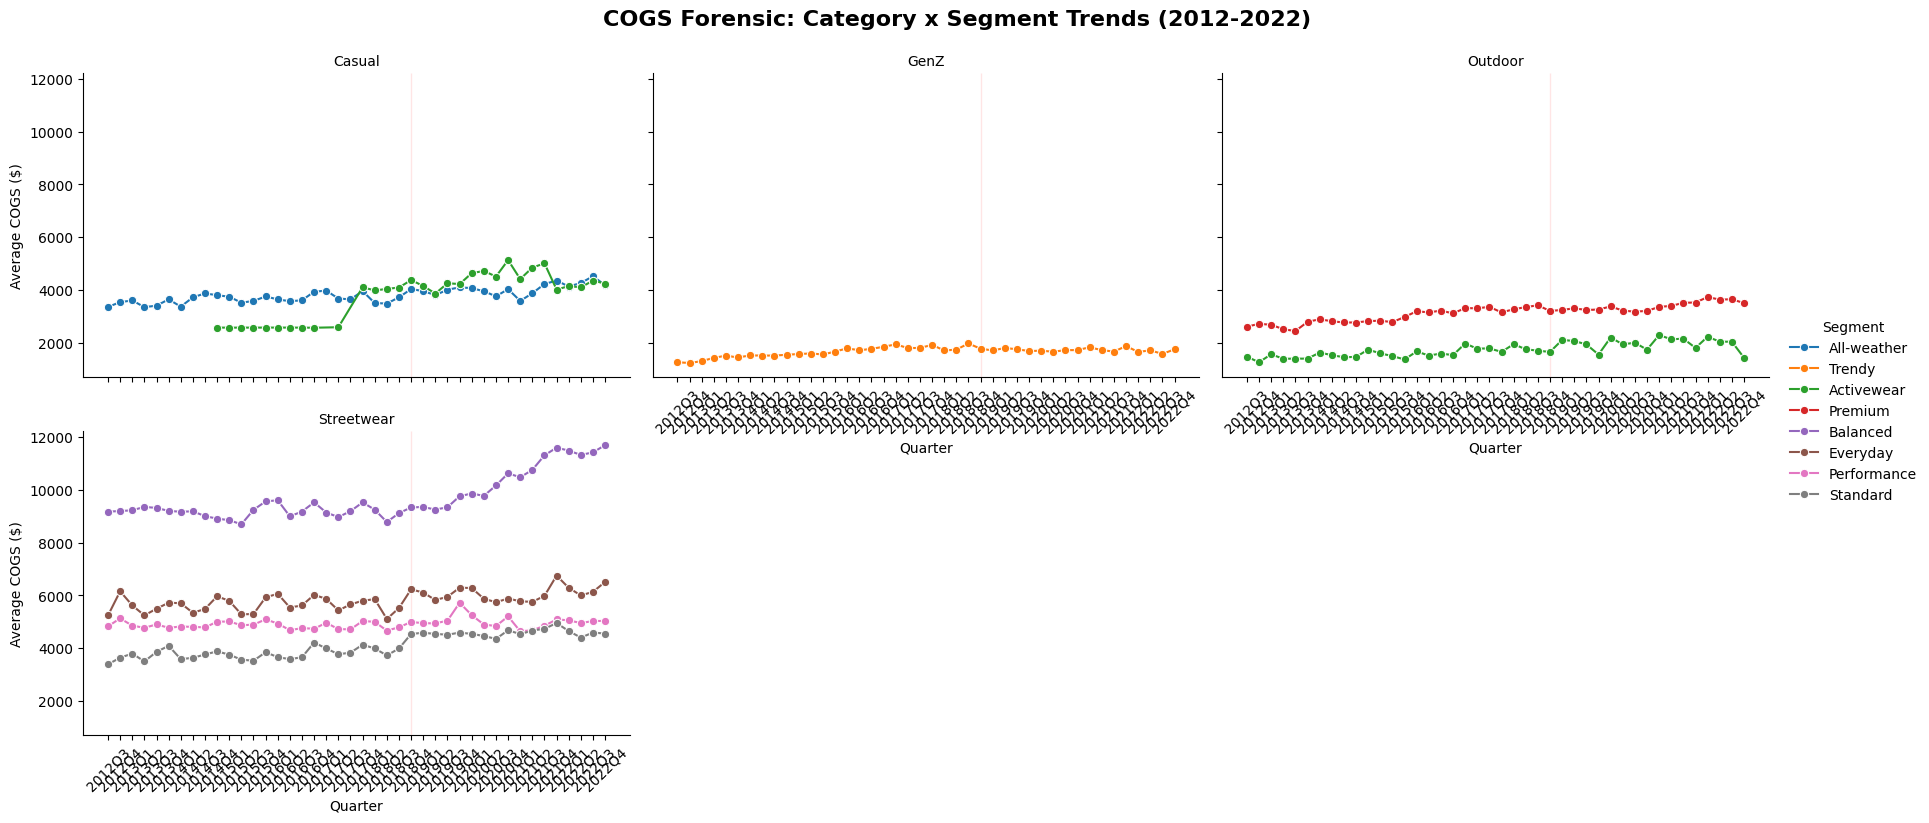

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data
data_path = Path(r"C:\DATATHON ROUND1")
orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Merge Financials with Product Attributes
# Ensure we have the Date (Orders), Attributes (Products), and Quantity (Items)
df_cogs = order_items.merge(products[['product_id', 'category', 'segment', 'cogs']], on='product_id')
df_cogs = df_cogs.merge(orders[['order_id', 'order_date']], on='order_id')

# 3. Aggregate by Time (Quarter), Category, and Segment
df_cogs['quarter'] = df_cogs['order_date'].dt.to_period('Q').astype(str)
cogs_trend = df_cogs.groupby(['quarter', 'category', 'segment'])['cogs'].mean().reset_index()

# 4. Visualization: Using FacetGrid to separate Categories
# This creates a clear small-multiple view for each category
g = sns.FacetGrid(cogs_trend, col="category", hue="segment", col_wrap=3, height=4, aspect=1.5)
g.map(sns.lineplot, "quarter", "cogs", marker='o')

# Formatting
g.add_legend(title="Segment")
g.set_axis_labels("Quarter", "Average COGS ($)")
g.set_titles("{col_name}")

# Rotate x-labels for clarity
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    # Add the Red Crash Zone to every subplot
    if '2018Q4' in cogs_trend['quarter'].values:
        ax.axvspan(list(cogs_trend['quarter'].unique()).index('2018Q4'), 
                   list(cogs_trend['quarter'].unique()).index('2018Q4'), 
                   color='red', alpha=0.1)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('COGS Forensic: Category x Segment Trends (2012-2022)', fontsize=16, fontweight='bold')
plt.show()

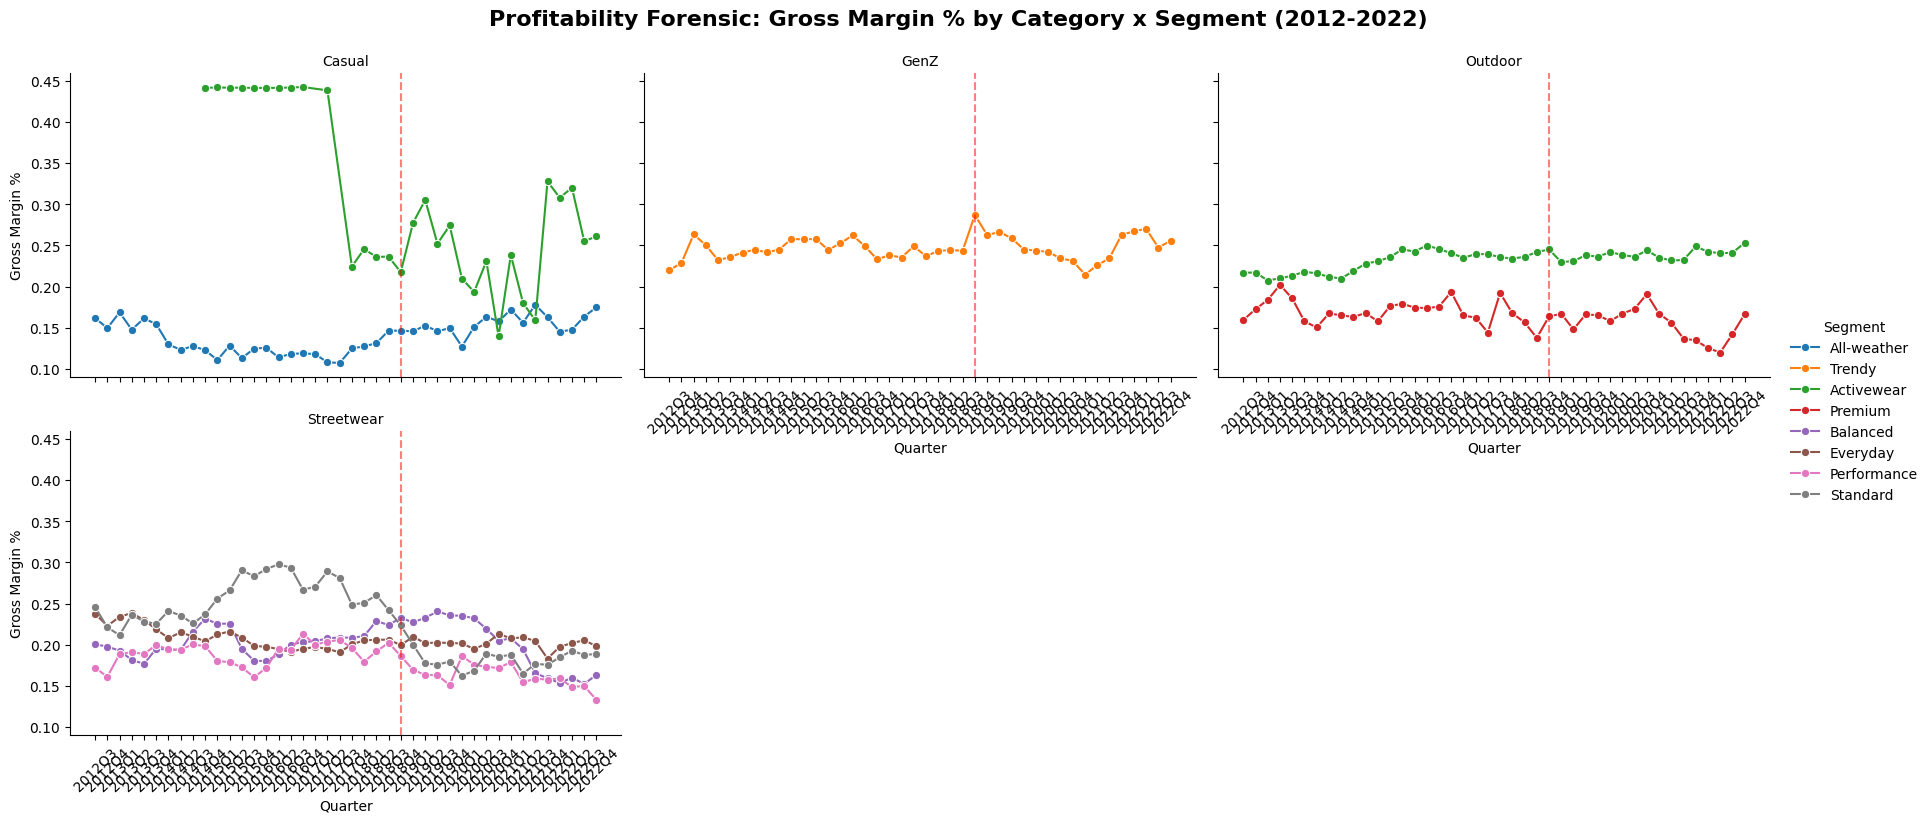

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data
data_path = Path(r"C:\DATATHON ROUND1")
orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Merge and Calculate Margin
df_margin = order_items.merge(products[['product_id', 'category', 'segment', 'cogs', 'price']], on='product_id')
df_margin = df_margin.merge(orders[['order_id', 'order_date']], on='order_id')

# Gross Margin % = (Price - COGS) / Price
df_margin['gross_margin'] = (df_margin['price'] - df_margin['cogs']) / df_margin['price']
df_margin['quarter'] = df_margin['order_date'].dt.to_period('Q').astype(str)

# 3. Aggregate
margin_trend = df_margin.groupby(['quarter', 'category', 'segment'])['gross_margin'].mean().reset_index()

# 4. Visualization: FacetGrid for Category-specific segmentation
g = sns.FacetGrid(margin_trend, col="category", hue="segment", col_wrap=3, height=4, aspect=1.5)
g.map(sns.lineplot, "quarter", "gross_margin", marker='o')

# Formatting
g.add_legend(title="Segment")
g.set_axis_labels("Quarter", "Gross Margin %")
g.set_titles("{col_name}")

# Rotate x-labels and add crash highlight
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    if '2018Q4' in margin_trend['quarter'].values:
        # Find index of 2018Q4 to draw vertical line/span
        quarters = sorted(margin_trend['quarter'].unique())
        if '2018Q4' in quarters:
            idx = quarters.index('2018Q4')
            ax.axvline(idx, color='red', linestyle='--', alpha=0.5)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Profitability Forensic: Gross Margin % by Category x Segment (2012-2022)', fontsize=16, fontweight='bold')
plt.show()

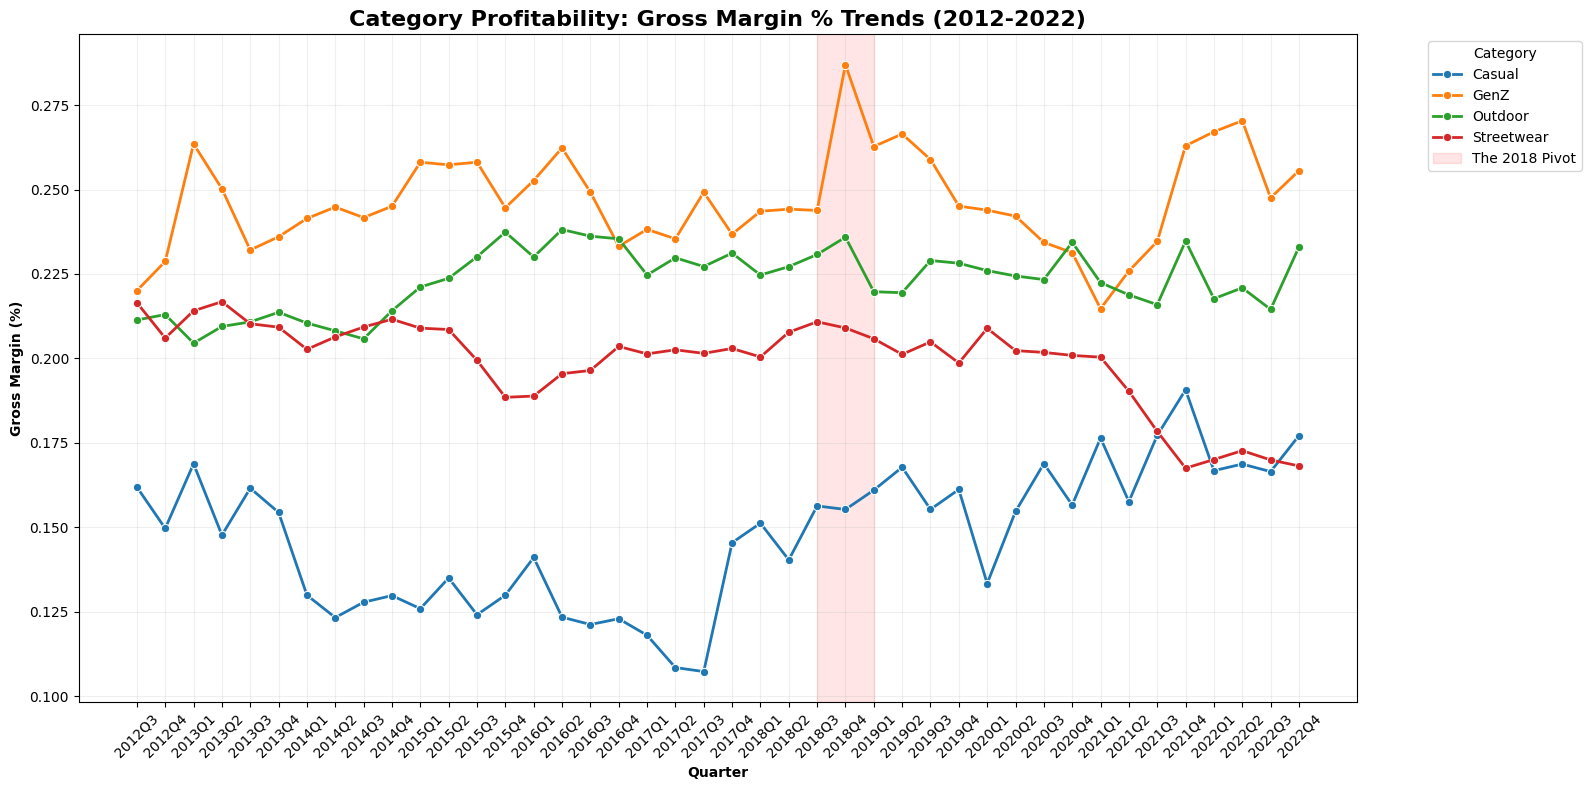

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Load Data
data_path = Path(r"C:\DATATHON ROUND1")
orders = pd.read_csv(data_path / "orders.csv", parse_dates=['order_date'])
order_items = pd.read_csv(data_path / "order_items.csv")
products = pd.read_csv(data_path / "products.csv")

# 2. Merge and Calculate
df_cat = order_items.merge(products[['product_id', 'category', 'cogs', 'price']], on='product_id')
df_cat = df_cat.merge(orders[['order_id', 'order_date']], on='order_id')

# Gross Margin % = (Price - COGS) / Price
df_cat['gross_margin'] = (df_cat['price'] - df_cat['cogs']) / df_cat['price']
df_cat['quarter'] = df_cat['order_date'].dt.to_period('Q').astype(str)

# 3. Aggregate by Quarter and Category
cat_margin_trend = df_cat.groupby(['quarter', 'category'])['gross_margin'].mean().reset_index()

# 4. Visualization
plt.figure(figsize=(16, 8))
sns.lineplot(data=cat_margin_trend, x='quarter', y='gross_margin', hue='category', marker='o', linewidth=2)

# Formatting
plt.title('Category Profitability: Gross Margin % Trends (2012-2022)', fontsize=16, fontweight='bold')
plt.ylabel('Gross Margin (%)', fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)

# Highlight the 2018 Crash Zone
if '2018Q4' in cat_margin_trend['quarter'].values:
    # Use index-based shading for time series
    quarters = sorted(cat_margin_trend['quarter'].unique())
    idx = quarters.index('2018Q4')
    plt.axvspan(idx-1, idx+1, color='red', alpha=0.1, label='The 2018 Pivot')

plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()